# Lecture 5: Time Series Features

*DASCI 270 - Time Series Analysis*

*Prepared by Sebastian C. Ibañez, PhD*

*Based on [FPPY Chapter 4](https://otexts.com/fpppy/nbs/04-features.html)*

`Prediction is very difficult, especially about the future. - Niels Bohr`

We have already encountered some time series features. For example, the autocorrelations discussed previously can be considered features of a time series, as they are numerical summaries computed from the data.

By computing various features for numerous time series, we can explore their underlying properties. This notebook will introduce several features that are valuable for time series exploration and demonstrate how they can reveal interesting insights from your data. We will primarily use the [`tsfeatures`](https://github.com/Nixtla/tsfeatures) package for this purpose.


In [1]:
%%capture
!pip install tsfeatures

!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_tourism.csv' -P ./data/

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tsfeatures import *
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

pd.set_option("display.precision", 3)
np.set_printoptions(suppress=True)

def plot_series(df, time_col, target_col, ylabel, xlabel, title):
  df = df.set_index(time_col)
  df[target_col].plot()
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.autoscale()
  plt.show()

## Some simple statistics

Any numerical summary computed from a time series—such as the mean, minimum, or maximum—is a feature of that series.

For example, let's compute the mean for each series in the Australian tourism dataset.

In [3]:
df_aus_tourism = pd.read_csv('data/aus_tourism.csv', parse_dates=['ds']) # unique_id is region-state-purpose
df_aus_tourism

,unique_id,ds,y
0,Adelaide-South Australia-Business,1998-03-31,135.078
1,Adelaide-South Australia-Business,1998-06-30,109.987
2,Adelaide-South Australia-Business,1998-09-30,166.035
3,Adelaide-South Australia-Business,1998-12-31,127.160
4,Adelaide-South Australia-Business,1999-03-31,137.449
...,...,...,...
24315,Yorke Peninsula-South Australia-Visiting,2016-12-31,33.672
24316,Yorke Peninsula-South Australia-Visiting,2017-03-31,46.223
24317,Yorke Peninsula-South Australia-Visiting,2017-06-30,50.583
24318,Yorke Peninsula-South Australia-Visiting,2017-09-30,27.767


In [4]:
df_aus_tourism.pivot(index='ds', columns='unique_id', values='y')

unique_id,Adelaide Hills-South Australia-Business,Adelaide Hills-South Australia-Holiday,Adelaide Hills-South Australia-Other,Adelaide Hills-South Australia-Visiting,Adelaide-South Australia-Business,Adelaide-South Australia-Holiday,Adelaide-South Australia-Other,Adelaide-South Australia-Visiting,Alice Springs-Northern Territory-Business,Alice Springs-Northern Territory-Holiday,...,Wilderness West-Tasmania-Other,Wilderness West-Tasmania-Visiting,Wimmera-Victoria-Business,Wimmera-Victoria-Holiday,Wimmera-Victoria-Other,Wimmera-Victoria-Visiting,Yorke Peninsula-South Australia-Business,Yorke Peninsula-South Australia-Holiday,Yorke Peninsula-South Australia-Other,Yorke Peninsula-South Australia-Visiting
ds,,,,,,,,,,,,,,,,,,,,,
1998-03-31,0.000,6.810,0.000,2.988,135.078,223.557,58.363,241.556,7.535,8.147,...,0.726,1.346,2.482,1.815,0.000,14.508,10.851,113.029,4.487,32.315
1998-06-30,0.000,13.672,4.642,7.753,109.987,130.287,39.469,170.111,3.356,34.660,...,0.000,1.877,17.791,14.105,2.608,17.978,2.575,63.155,3.212,35.382
1998-09-30,7.418,12.921,2.555,3.597,166.035,156.089,38.432,232.349,21.778,76.541,...,0.000,1.127,5.555,13.781,0.000,16.321,16.228,40.422,0.000,12.346
1998-12-31,0.000,18.137,0.774,8.345,127.160,182.329,33.792,180.962,3.977,27.221,...,0.000,0.329,3.925,3.926,0.000,19.353,1.344,69.658,0.514,31.824
1999-03-31,0.670,10.905,0.000,2.198,137.449,185.332,25.902,199.712,18.412,12.496,...,0.000,4.030,14.102,25.087,0.000,11.031,1.215,106.276,0.525,38.643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31,0.117,14.343,0.368,37.566,152.429,147.102,83.549,251.292,21.955,15.233,...,0.000,0.292,0.000,12.819,0.000,12.891,3.078,45.771,1.407,33.672
2017-03-31,0.979,12.919,0.684,22.387,129.029,215.940,93.827,269.536,18.588,21.145,...,0.000,2.419,22.577,19.091,0.490,20.776,2.324,94.862,6.854,46.223
2017-06-30,4.303,19.055,0.923,31.475,173.736,201.734,82.589,218.394,34.077,39.030,...,0.000,0.580,1.057,5.788,0.000,35.000,9.626,63.654,2.069,50.583


In [5]:
df_mean = df_aus_tourism.groupby("unique_id", as_index=False)['y'].mean()
df_mean.sort_values(by='y', ascending=True).head(10)

,unique_id,y
158,Kangaroo Island-South Australia-Other,0.340
182,MacDonnell-Northern Territory-Other,0.449
294,Wilderness West-Tasmania-Other,0.478
34,Barkly-Northern Territory-Other,0.632
86,Clare Valley-South Australia-Other,0.898
38,Barossa-South Australia-Other,1.022
154,Kakadu Arnhem-Northern Territory-Other,1.043
170,Lasseter-Northern Territory-Other,1.136
298,Wimmera-Victoria-Other,1.146
183,MacDonnell-Northern Territory-Visiting,1.175


The output shows that the series with the lowest average number of visits is for "Other" purposes to Kangaroo Island, South Australia.

Rather than computing one feature at a time, it is more convenient to compute many features at once.

In [6]:
summary_stats = tsfeatures(df_aus_tourism, freq=4, features=[statistics], scale=False)
summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(10)

,unique_id,min,p25,median,p75,max
0,Adelaide Hills-South Australia-Business,0.000,0.000,1.255,3.920,28.602
1,Adelaide Hills-South Australia-Holiday,0.000,5.768,8.516,14.060,35.751
2,Adelaide Hills-South Australia-Other,0.000,0.000,0.908,2.093,8.953
3,Adelaide Hills-South Australia-Visiting,0.778,8.908,12.207,16.806,81.102
4,Adelaide-South Australia-Business,68.725,133.893,152.577,176.936,242.494
5,Adelaide-South Australia-Holiday,108.033,134.627,153.945,172.257,223.557
6,Adelaide-South Australia-Other,25.902,43.866,53.809,62.523,107.495
7,Adelaide-South Australia-Visiting,136.611,178.916,205.582,229.299,269.536
8,Alice Springs-Northern Territory-Business,1.008,9.133,13.324,18.456,34.077
9,Alice Springs-Northern Territory-Holiday,2.809,16.851,31.524,44.784,76.541


## ACF features

All the autocorrelations of a series can be considered features of that series.

We can also summarise the autocorrelations to produce new features. For example:
- **Sum of Squares:** A useful summary is the sum of the first ten squared autocorrelation coefficients. This single number indicates the total amount of autocorrelation in the series.
- **Differencing:** We can analyze the change from one period to the next by "differencing" the series (i.e., `value_today - value_yesterday`). The autocorrelations of this new differenced series are valuable features. Sometimes, this process is repeated to create a "double-differenced" series.
- **Seasonal Differencing:** To analyze year-over-year changes, we can use "seasonal differencing." For instance, with quarterly data, you would compare Q1 of this year to Q1 of last year. The autocorrelations of this seasonally adjusted series offer important insights into seasonal patterns.

In [7]:
acf_feat = tsfeatures(df_aus_tourism, freq=4, features=[acf_features])
acf_feat.head(10)

,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,0.071,0.134,-0.580,0.415,-0.750,0.746,-0.063
1,Adelaide Hills-South Australia-Holiday,0.131,0.313,-0.536,0.500,-0.716,0.906,0.208
2,Adelaide Hills-South Australia-Other,0.261,0.330,-0.253,0.317,-0.457,0.392,0.075
3,Adelaide Hills-South Australia-Visiting,0.139,0.117,-0.472,0.239,-0.626,0.408,0.170
4,Adelaide-South Australia-Business,0.033,0.131,-0.520,0.463,-0.676,0.741,0.201
5,Adelaide-South Australia-Holiday,0.046,0.372,-0.343,0.614,-0.487,0.558,0.351
6,Adelaide-South Australia-Other,0.517,1.154,-0.409,0.383,-0.675,0.792,0.342
7,Adelaide-South Australia-Visiting,0.068,0.294,-0.394,0.452,-0.518,0.447,0.345
8,Alice Springs-Northern Territory-Business,0.217,0.367,-0.500,0.381,-0.658,0.587,0.315
9,Alice Springs-Northern Territory-Holiday,-0.007,2.113,-0.153,2.113,-0.274,1.551,0.729


Setting features=[acf_features] computes a selection of the autocorrelations discussed here. It will return six or seven features:

- `x_acf1`: The first autocorrelation coefficient from the original series.
- `x_acf10`: The sum of squares of the first ten autocorrelation coefficients from the original series.
- `diff1_acf1`: The first autocorrelation coefficient from the differenced series.
- `diff1_acf10`: The sum of squares of the first ten autocorrelation coefficients from the differenced series.
- `diff2_acf1`: The first autocorrelation coefficient from the twice-differenced series.
- `diff2_acf10`: The sum of squares of the first ten autocorrelation coefficients from the twice-differenced series.
- `seas_acf1`: For seasonal data, the autocorrelation coefficient at the first seasonal lag.

## STL features

A time series decomposition can be used to measure the strength of trend and seasonality in a time series. Recall the STL decomposition equation:

\begin{align*}
    y_t &= S_t + T_t + R_t
\end{align*}

For strongly trended series, the seasonally adjusted data $(T_t + R_t)$ should have much more variation than the remainder component $(R_t)$ alone. Therefore, the ratio $\text{Var}(R_t)/\text{Var}(T_t + R_t)$ will be relatively small. For data with little or no trend, the two variances will be approximately the same. Thus, we can define the **strength of trend** as:

\begin{align*}
    F_T &= \text{max}\left( 0 , 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)} \right)
\end{align*}

Similarly, we can define the **strength of seasonality** as,

\begin{align*}
    F_S &= \text{max}\left( 0 , 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)} \right)
\end{align*}

Series with $F_S$ close to $0$ exhibits almost no seasonality, while those with strong seasonality will have their value be close to $1$.

These measures are particularly useful when working with a large collection of time series, as they allow you to programmatically identify and rank series by their trend and seasonality strength.

In [8]:
stl_feat = tsfeatures(df_aus_tourism, freq=4, features=[stl_features])
stl_feat.head(10)

,unique_id,nperiods,seasonal_period,trend,spike,linearity,curvature,e_acf1,e_acf10,seasonal_strength,peak,trough
0,Adelaide Hills-South Australia-Business,1,4,0.460,3.223e-04,0.278,-0.627,-0.594,0.502,0.168,3,4
1,Adelaide Hills-South Australia-Holiday,1,4,0.531,1.048e-04,1.669,3.925,-0.456,0.342,0.295,2,4
2,Adelaide Hills-South Australia-Other,1,4,0.590,5.346e-05,2.486,1.898,-0.295,0.273,0.407,2,2
3,Adelaide Hills-South Australia-Visiting,1,4,0.487,5.798e-04,3.231,-0.125,-0.474,0.438,0.248,4,3
4,Adelaide-South Australia-Business,1,4,0.462,9.712e-05,-0.106,2.049,-0.538,0.577,0.391,3,1
5,Adelaide-South Australia-Holiday,1,4,0.578,1.717e-05,1.850,3.028,-0.525,0.600,0.638,1,2
6,Adelaide-South Australia-Other,1,4,0.746,2.364e-05,5.548,2.493,-0.368,0.412,0.209,2,3
7,Adelaide-South Australia-Visiting,1,4,0.449,4.824e-05,1.033,2.267,-0.504,1.000,0.476,1,2
8,Alice Springs-Northern Territory-Business,1,4,0.552,5.246e-05,3.299,2.586,-0.481,0.519,0.302,3,1
9,Alice Springs-Northern Territory-Holiday,1,4,0.379,6.707e-06,-1.076,0.634,-0.529,0.709,0.832,3,1


We can then use these features in plots to identify which types of series are strongly trended and which are highly seasonal.

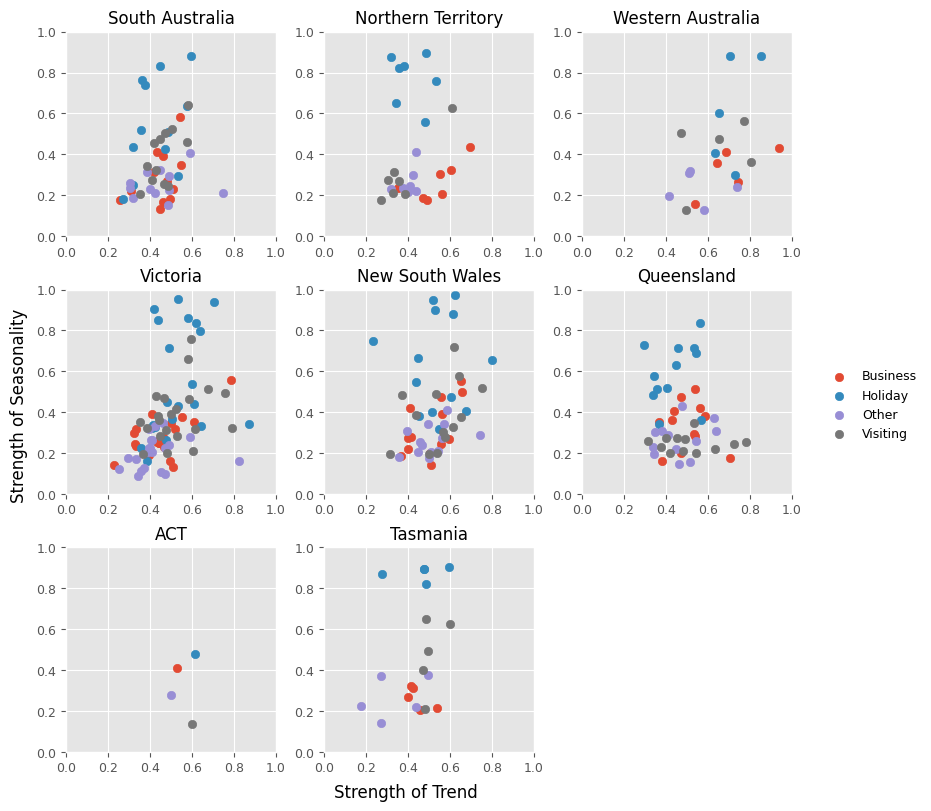

In [12]:
stl_feat[["region", "state", "purpose"]] = stl_feat["unique_id"].str.split(
    "-", expand=True
)

fig, axs = plt.subplots(3, 3, figsize=(8, 8))
axs = axs.flatten()
unique_states = stl_feat["state"].unique()
all_handles = []
all_labels = []
for i, state in enumerate(unique_states):
    state_df = stl_feat.query("state == @state")
    ax = axs[i]
    for purpose in state_df["purpose"].unique():
        purpose_df = state_df[state_df["purpose"] == purpose]
        handle = ax.scatter(
            purpose_df["trend"], purpose_df["seasonal_strength"],
            label=purpose
        )
        if purpose not in all_labels:
            all_handles.append(handle)
            all_labels.append(purpose)
    ax.set_title(state)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
fig.legend(
    all_handles, all_labels, loc="center left", bbox_to_anchor=(1.02, .5),
    frameon=False, borderaxespad=0,
)
fig.supxlabel('Strength of Trend')
fig.supylabel('Strength of Seasonality')

# Remove any empty subplots
for j in range(len(unique_states), len(axs)):
    fig.delaxes(axs[j])

plt.show()

The plot clearly shows that 'Holiday' series are the most seasonal, which is an intuitive finding. The series with the strongest trends appear to be concentrated in Western Australia and Victoria.

We can also use these features to programmatically identify and plot the single most seasonal series.

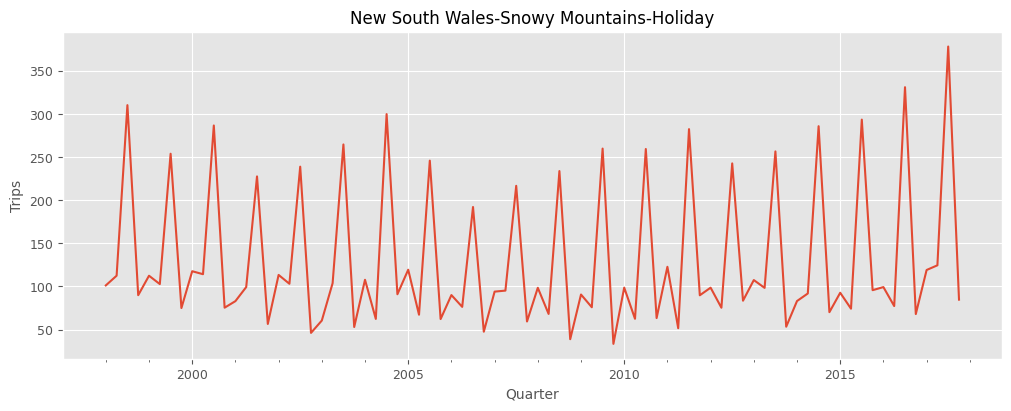

In [21]:
max_seasonal_strength_row = stl_feat.loc[stl_feat["seasonal_strength"].idxmax()]
max_unique_id = max_seasonal_strength_row["unique_id"]

plot_series(df_aus_tourism[df_aus_tourism['unique_id'] == max_unique_id],
            time_col="ds",
            target_col="y",
            xlabel="Quarter",
            ylabel="Trips",
            title="New South Wales-Snowy Mountains-Holiday")

This plot shows holiday trips to the Snowy Mountains in New South Wales, the most popular ski region in Australia.

The `stl_features` function returns several other useful features:

- `peak` & `trough`: Indicate the timing of the seasonal peak and trough (i.e., the quarter with the largest and smallest seasonal component, respectively). This reveals the nature of the seasonality (e.g., winter vs. summer holiday destinations).
- `spike`: Measures the prevalence of spikes in the remainder component.
- `linearity` & `curvature`: Measure the linearity and curvature of the trend component, based on coefficients from linear and quadratic regressions, respectively.
- `e_acf1` & `e_acf10`: The first autocorrelation coefficient and the sum of squares of the first ten autocorrelation coefficients of the remainder series.

## Other features

Many other features can be engineered. The `tsfeatures` library includes a few dozen that have proven useful in time series analysis. You can also easily define your own custom features by writing a Python function that takes a univariate time series as input and returns a numerical vector of feature values.

The remaining features in the `tsfeatures` library are listed here for reference:

- `hurst`: Calculates the Hurst coefficient, a measure of "long memory." A series with long memory has significant autocorrelations across many lags.
- `entropy`: Computes the Shannon spectral entropy. A series with strong, predictable patterns (like trend and seasonality) will have entropy close to 0, while a noisy, unpredictable series will have entropy close to 1.
- `box_pierce` & `ljung_box`: Return the Box-Pierce and Ljung-Box test statistics and their corresponding p-values for testing if a series is white noise.
- `pacf_features`: Computes features based on the Partial Autocorrelation Function (PACF). The $k$-th partial autocorrelation measures the relationship between observations $k$ periods apart after removing the effects of the intermediate observations.
- `n_crossing_points`: Computes the number of times the time series crosses its median value.
- `stat_arch_lm`: Returns the statistic from the Lagrange Multiplier (LM) test for autoregressive conditional heteroscedasticity (ARCH).
- `guerrero`: Computes the optimal $\lambda$ value for a Box-Cox transformation using the Guerrero method.

## Exploring Australian tourism data

All of the features available in the `tsfeatures` package can be computed at once as follows:

In [22]:
all_features = [
    acf_features,
    arch_stat,
    crossing_points,
    entropy,
    flat_spots,
    heterogeneity,
    holt_parameters,
    lumpiness,
    nonlinearity,
    pacf_features,
    stl_features,
    stability,
    hw_parameters,
    unitroot_kpss,
    unitroot_pp,
    series_length,
    hurst,
]
all_feat = tsfeatures(df_aus_tourism, freq=4, features=all_features)
all_feat

,unique_id,hurst,series_length,unitroot_pp,unitroot_kpss,hw_alpha,hw_beta,hw_gamma,stability,nperiods,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,NaN,80,-80.527,0.060,1.491e-08,1.520e-09,0.000e+00,0.294,1,...,0.895,36,0.014,0.071,0.134,-0.580,0.415,-0.750,0.746,-0.063
1,Adelaide Hills-South Australia-Holiday,0.823,80,-74.302,0.476,9.899e-02,9.899e-02,0.000e+00,0.409,1,...,0.831,33,0.121,0.131,0.313,-0.536,0.500,-0.716,0.906,0.208
2,Adelaide Hills-South Australia-Other,0.599,80,-55.385,0.605,1.490e-08,2.417e-09,1.799e-01,0.274,1,...,0.862,37,0.265,0.261,0.330,-0.253,0.317,-0.457,0.392,0.075
3,Adelaide Hills-South Australia-Visiting,0.757,80,-71.076,0.749,1.490e-08,3.758e-09,0.000e+00,0.333,1,...,0.907,25,0.005,0.139,0.117,-0.472,0.239,-0.626,0.408,0.170
4,Adelaide-South Australia-Business,0.840,80,-78.764,0.221,1.306e-01,1.306e-01,0.000e+00,0.318,1,...,0.848,43,0.183,0.033,0.131,-0.520,0.463,-0.676,0.741,0.201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,Wimmera-Victoria-Visiting,0.749,80,-63.557,0.234,1.491e-08,1.409e-09,0.000e+00,0.297,1,...,0.865,41,0.068,0.158,0.082,-0.394,0.233,-0.631,0.520,0.009
300,Yorke Peninsula-South Australia-Business,0.692,80,-72.001,0.289,1.490e-08,5.375e-09,0.000e+00,0.243,1,...,0.839,41,0.082,0.031,0.118,-0.405,0.300,-0.559,0.385,0.219
301,Yorke Peninsula-South Australia-Holiday,0.313,80,-54.026,0.087,1.490e-08,6.297e-09,5.550e-13,0.065,1,...,0.432,40,0.414,-0.005,2.013,-0.144,2.060,-0.256,1.571,0.579
302,Yorke Peninsula-South Australia-Other,0.565,80,-100.935,0.487,1.490e-08,6.218e-09,5.026e-12,0.253,1,...,0.892,43,0.793,-0.107,0.149,-0.634,0.622,-0.689,0.779,0.161


This process generates a dataframe with 42 features for each unique time series (i.e., for every combination of Region, State, and Purpose). We can now analyze this feature dataframe to find interesting patterns or groupings.

As we saw earlier, we can plot one feature against another. For a more comprehensive view, we can create a pairwise plot (or scatterplot matrix) for a group of related features.

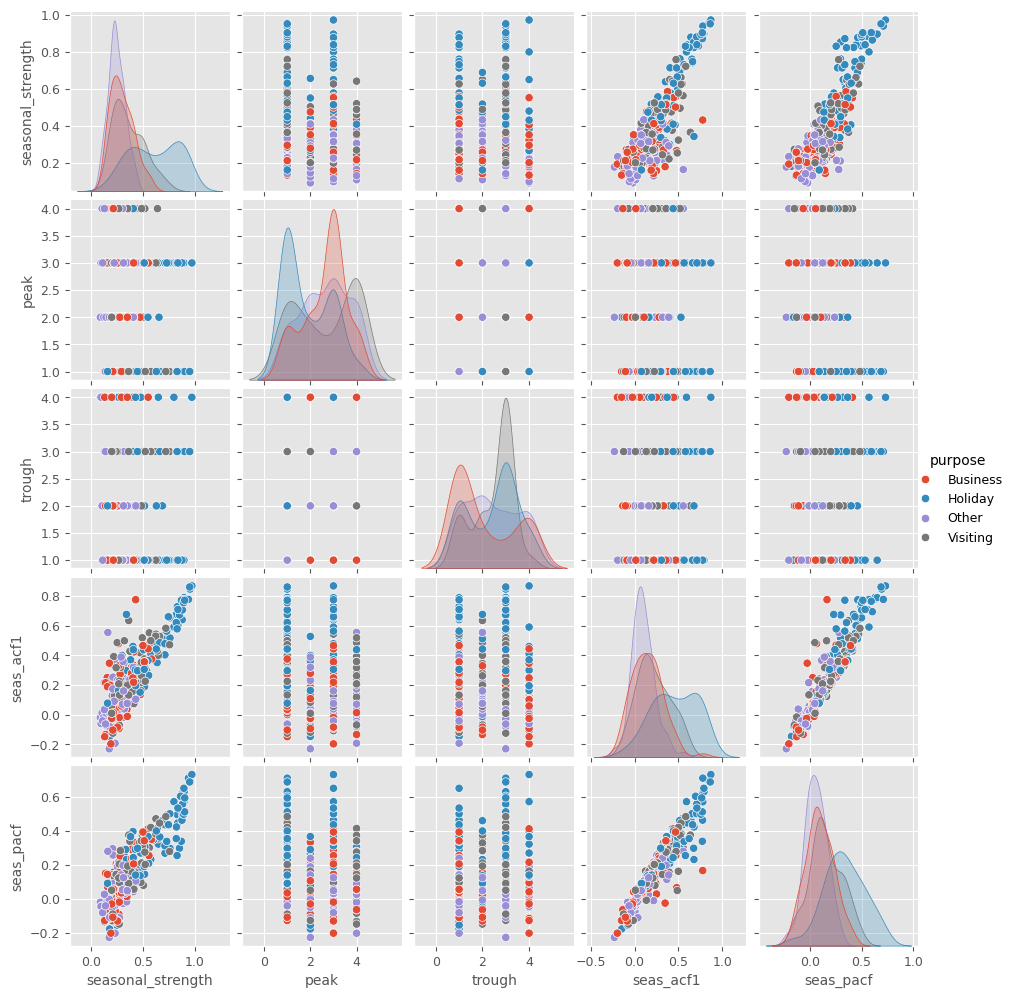

In [23]:
# analyze features that involve seasonality
seasonal_feat = all_feat[["unique_id", "seasonal_strength", "peak", "trough", "seas_acf1", "seas_pacf"]]

seasonal_feat[["region", "state", "purpose"]] = seasonal_feat["unique_id"].str.split("-", expand=True)
g = sns.pairplot(seasonal_feat, hue="purpose")
g.fig.set_size_inches(10, 10)
plt.show()

Here, the `Purpose` variable is mapped to colour. This visualization contains a wealth of information; we will highlight a few key observations:

- The three numerical measures of seasonality (`seasonal_strength`, `seas_acf1`, and `seas_pacf`) are all strongly and positively correlated with each other.
- The plots confirm our earlier finding: the most strongly seasonal series are overwhelmingly for 'Holiday' purposes.
- The bar plots for `peak` and `trough` show that seasonal peaks in 'Business' travel occur most often in Quarter 3 and least often in Quarter 1.

### Feature Visualization with PCA

Exploring many features simultaneously with pair plots becomes difficult. A powerful technique for visualizing a high-dimensional feature space is dimension reduction. **Principal Component Analysis (PCA)** is one such method. It finds linear combinations of the original features (called principal components) that capture the most variance in the data.

We can compute the principal components of the tourism features as follows:

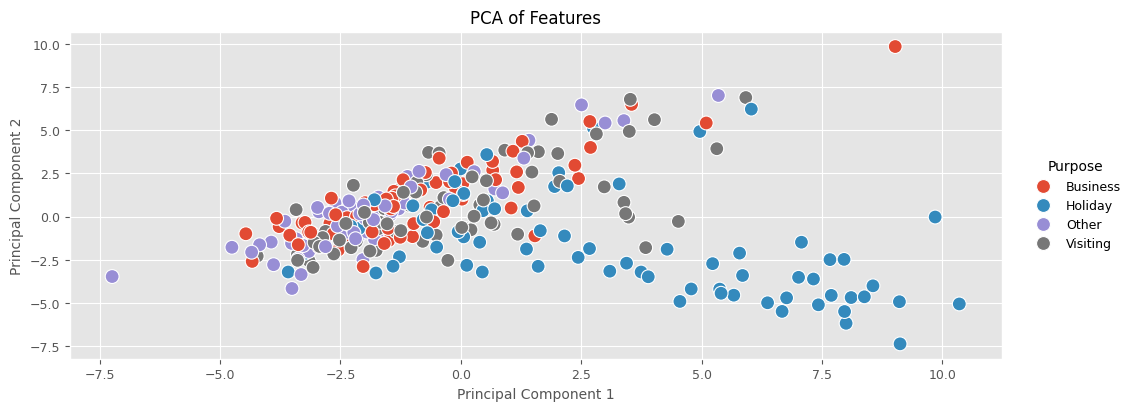

In [24]:
all_feat['purpose'] = all_feat['unique_id'].str.split('-').str[-1]
all_feat = all_feat.dropna(axis=1)

features = all_feat.columns.drop(["unique_id", "purpose"])
X = all_feat[features]
y = all_feat["purpose"]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Plotting the first two PCA components
pca_df = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
pca_df["purpose"] = y

fig, ax = plt.subplots()
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="purpose", s=100, ax=ax)
ax.set_title("PCA of Features")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Purpose", loc="center left", bbox_to_anchor=(1.02, .5),
    frameon=False, borderaxespad=0)
plt.show()

Each point in the plot above represents a single time series, positioned according to its values for the first two principal components. The first principal component (PC1) is the linear combination of the original features that explains the most variation in the data. The second principal component (PC2) is the linear combination that explains the most remaining variation, while being uncorrelated with PC1.

A few patterns are immediately clear:

- The 'Holiday' series are clearly separated from the other series. Almost all 'Holiday' series appear in the bottom half of the plot, while the remaining series are in the top half.

- This suggests that the second principal component (PC2) is effective at distinguishing 'Holiday' travel from other types.

The PCA plot is also excellent for identifying **outliers**—time series with unusual combinations of features. These appear as points that are isolated from the main clusters. We can see a few points that stand out, particularly those with high PC1 values. Let's identify and plot the top five series with the highest PC1 scores:

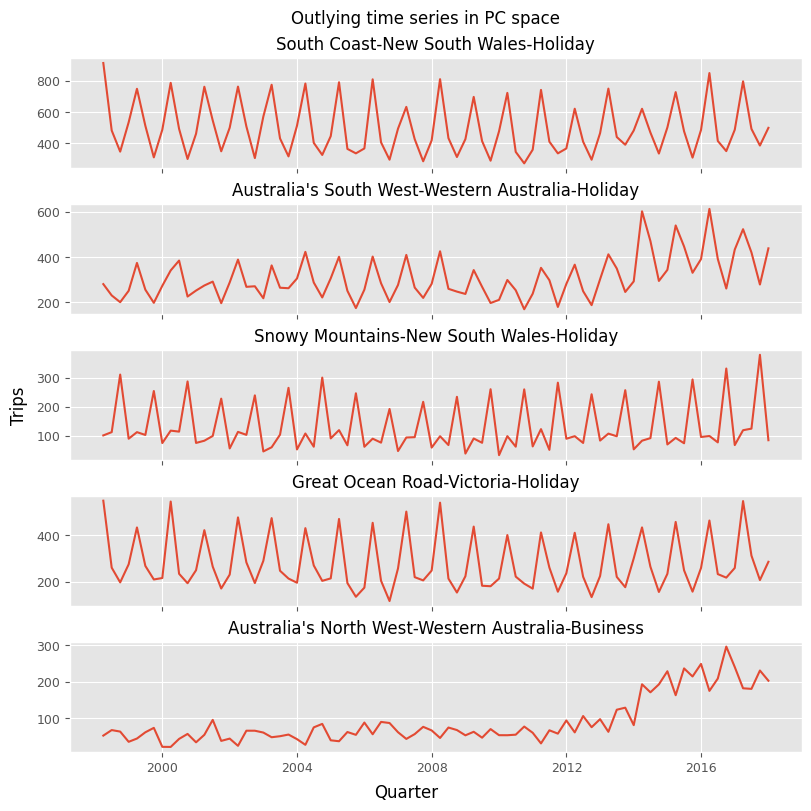

In [ ]:
pca_df["unique_id"] = all_feat["unique_id"]
top_unique_ids = pca_df.nlargest(5, "PC1")["unique_id"]
plot_df = df_aus_tourism[df_aus_tourism["unique_id"].isin(top_unique_ids)]

fig, axs = plt.subplots(5, 1, sharex=True, figsize=(8, 8))

for i, unique_id in enumerate(top_unique_ids):
    subset = plot_df[plot_df["unique_id"] == unique_id]
    axs[i].plot(subset["ds"], subset["y"])
    axs[i].set_title(unique_id)
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
fig.suptitle("Outlying time series in PC space", x=0.525)
fig.supylabel("Trips")
fig.supxlabel("Quarter")
plt.show()

We can speculate why these series are identified as unusual:

- **South Coast (NSW) Holiday**: This series is highly seasonal but shows almost no trend, unlike most other holiday destinations in Australia which have some trend over time.
- **Australia's South West (WA) Holiday**: This region is unusual because it exhibits both strong seasonality and a recent increase in holiday tourism.
- **Snowy Mountains (NSW) Holiday**: This series has extremely high seasonality (as seen earlier).
- **Great Ocean Road (VIC) Holiday**: This series shows very strong and consistent seasonality.
- **Australia's North West (WA) Business**: This outlier is unique because it shows a recent increase in business tourism but has little to no seasonality.